<a href="https://colab.research.google.com/github/h-muhammed/bank-churn-ml-classification/blob/main/notebooks/02_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Customer Churn Prediction
This notebook implements a Random Forest Classifier to predict customer churn based on the UCI Bank Marketing dataset.

### Step 1: Data Setup
We initialize the environment and load the raw data.

In [ ]:
import kagglehub
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
import joblib

# 1. Download the new dataset using kagglehub
download_path = kagglehub.dataset_download("shrutimechlearn/churn-modelling")

# 2. Define source and destination paths
csv_name = "Churn_Modelling.csv"
src_path = os.path.join(download_path, csv_name)
dest_path = os.path.join("/content/", csv_name)

# 3. Move the file to /content/ folder
if os.path.exists(src_path):
    shutil.copy(src_path, dest_path)
    print(f"File moved to: {dest_path}")

# 4. Load the data from /content/
df = pd.read_csv(dest_path)

print(f"Dataset Shape: {df.shape}")
display(df.head())

100%|██████████| 262k/262k [00:00<00:00, 28.0MB/s]

Extracting files...
File moved to: /content/Churn_Modelling.csv
Dataset Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Step 2: Data Preprocessing
We handle encoding, target transformation, and splitting.

In [ ]:
# Drop non-predictive columns
df_model = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Encode categorical variables (Geography, Gender)
cat_cols = df_model.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

# Define Features and Target (Exited is the churn flag in this dataset)
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Preprocessing complete. Training features: {X_train.shape[1]}")

Preprocessing complete. Training features: 11


### Step 3: Model Implementation & Training
Training the Random Forest with balanced class weights.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


### Step 4: Model Evaluation
Calculating Accuracy, F1, and AUC.

In [ ]:
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

Accuracy: 0.8345
F1 Score: 0.6147
ROC-AUC: 0.8638


### Step 5: Visualization
Plotting performance metrics.

Top 10 Feature Importances:
Age                  0.319148
NumOfProducts        0.209166
Balance              0.118376
EstimatedSalary      0.083226
CreditScore          0.078896
IsActiveMember       0.052679
Geography_Germany    0.051883
Tenure               0.043949
Gender_Male          0.022025
Geography_Spain      0.010606
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1593
           1       0.58      0.65      0.61       407

    accuracy                           0.83      2000
   macro avg       0.75      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000



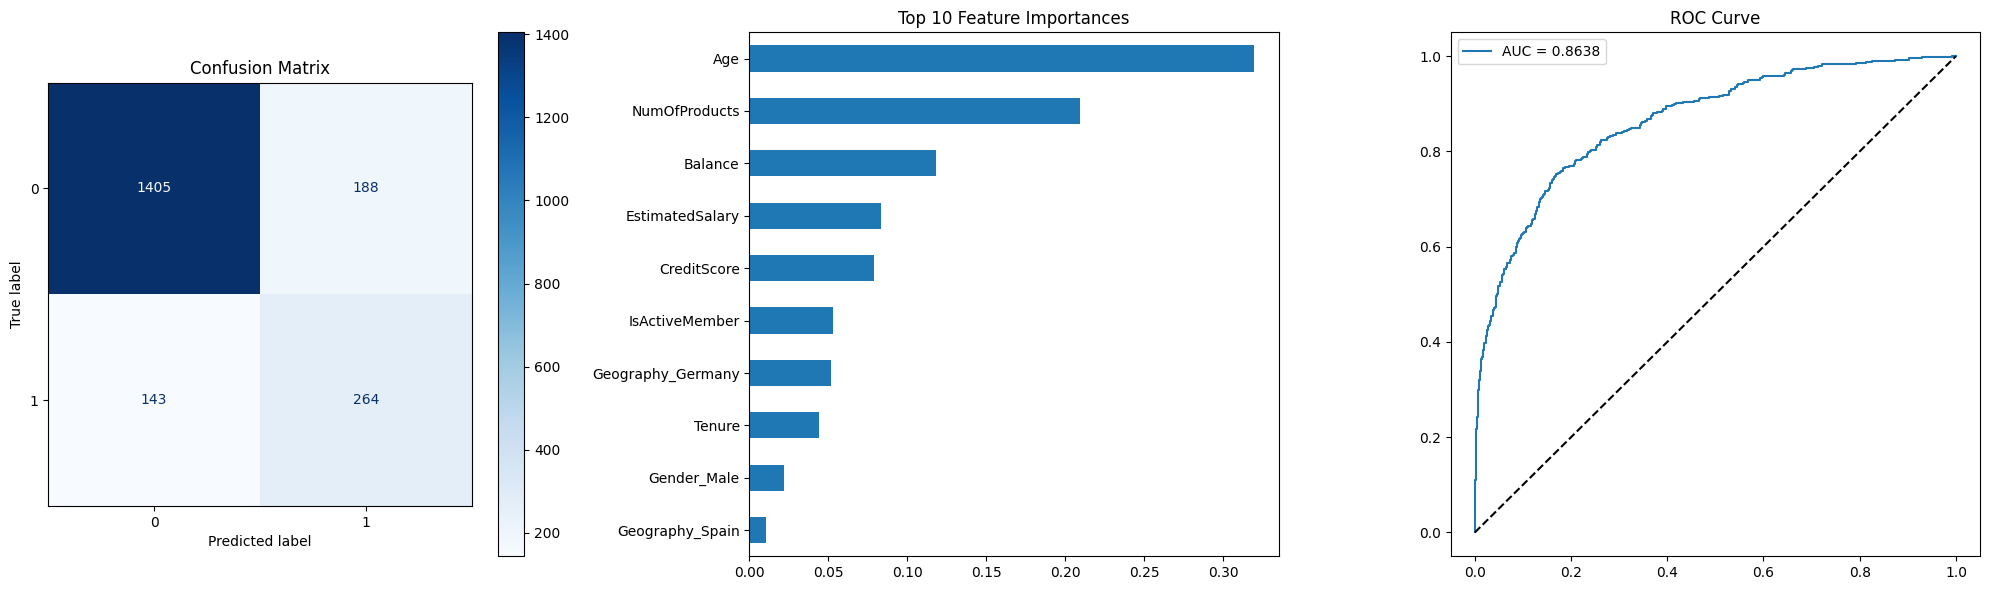

In [ ]:
# 1. Generate textual reports
from sklearn.metrics import classification_report

print("Top 10 Feature Importances:")
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
print(importances)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 2. Visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix')

# Feature Importance Plot
importances.plot(kind='barh', ax=axes[1])
axes[1].set_title('Top 10 Feature Importances')
axes[1].invert_yaxis()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[2].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title('ROC Curve')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Check class distribution in the original data
print("Original target distribution:")
# Updated from 'y' to 'Exited' for the new dataset
print(df['Exited'].value_counts(normalize=True))

# Check the confusion matrix values more closely
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix Detail:")
print(f"True Negatives (Correct No-Churn): {cm[0,0]}")
print(f"False Positives (Predicted Churn, was No-Churn): {cm[0,1]}")
print(f"False Negatives (Missed Churn): {cm[1,0]}")
print(f"True Positives (Correct Churn): {cm[1,1]}")

# Validate that the model isn't just predicting the majority class
unique_preds, counts_preds = np.unique(y_pred, return_counts=True)
print(f"\nModel Prediction Distribution: {dict(zip(unique_preds, counts_preds))}")

Original target distribution:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

Confusion Matrix Detail:
True Negatives (Correct No-Churn): 1405
False Positives (Predicted Churn, was No-Churn): 188
False Negatives (Missed Churn): 143
True Positives (Correct Churn): 264

Model Prediction Distribution: {np.int64(0): np.int64(1548), np.int64(1): np.int64(452)}


### Step 6: Model Saving & Inference
Exporting and testing the model.

In [ ]:
joblib.dump(rf_model, 'rf_churn_model.joblib')
loaded_model = joblib.load('rf_churn_model.joblib')
sample_pred = loaded_model.predict(X_test.iloc[:1])
print(f'Sample Prediction: {sample_pred[0]}')

Sample Prediction: 0


In [ ]:
import pandas as pd

# Define multiple scenarios to test the model's reaction
test_scenarios = pd.DataFrame([
    {
        'Scenario': 'High Risk (Older, Inactive, Germany)',
        'CreditScore': 600, 'Age': 50, 'Tenure': 3, 'Balance': 150000.0,
        'NumOfProducts': 3, 'HasCrCard': 1, 'IsActiveMember': 0,
        'EstimatedSalary': 50000.0, 'Geography_Germany': 1, 'Geography_Spain': 0, 'Gender_Male': 0
    },
    {
        'Scenario': 'Low Risk (Younger, Active, France)',
        'CreditScore': 700, 'Age': 30, 'Tenure': 5, 'Balance': 0.0,
        'NumOfProducts': 2, 'HasCrCard': 1, 'IsActiveMember': 1,
        'EstimatedSalary': 60000.0, 'Geography_Germany': 0, 'Geography_Spain': 0, 'Gender_Male': 1
    }
])

# Prepare features (dropping the 'Scenario' label for the model)
features = test_scenarios[X.columns]

# Predict
predictions = loaded_model.predict(features)
probabilities = loaded_model.predict_proba(features)[:, 1]

# Display results
for i, row in test_scenarios.iterrows():
    print(f"--- {row['Scenario']} ---")
    print(f"Result: {'CHURN' if predictions[i] == 1 else 'STAY'}")
    print(f"Probability: {probabilities[i]:.2%}\n")

--- High Risk (Older, Inactive, Germany) ---
Result: CHURN
Probability: 95.03%

--- Low Risk (Younger, Active, France) ---
Result: STAY
Probability: 4.20%

